# Introduction to Python: Numpy and Matplotlib

## Standard scientific libraries in Python

* Numpy: Array manipulation, functions to operate on arrays
* Scipy: Numerical algorithms - optimization, linear algebra, integration, interpolation, FFT, ...
* Pandas: Data manipulation and analysis; tables and data series
* scikit-learn: Machine learning - classification, regression, clustering, dimensionality reduction
* Visualization:
    * Matplotlib: Visualization, (mainly) 2D plotting
    * Seaborn: Statistical visualization, based on matplotlib
* Deep learning: PyTorch, TensorFlow

   
All of them are designed to operate well with numpy.



## Numpy basics

The official quick start guide: https://numpy.org/devdocs/user/quickstart.html

In [20]:
import numpy as np

In [64]:
a = np.array([[9, 4, 2, -1],[-1, 4, 7, 3]])

\
Each array has a dimension, a shape, and a type.

In [65]:
a.ndim, a.shape, a.dtype

(2, (2, 4), dtype('int64'))

\
Arrays can be created, indexed, sliced.

In [72]:
np.random.seed(42)

a = np.zeros((8,3), dtype=float)
b = np.random.uniform(-10, 10, (8,3))
c = np.arange(3)

print('\nArray a:\n', a)
print('\nArray b:\n', b)
print('\nArray c:\n', c)


Array a:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Array b:
 [[-2.50919762  9.01428613  4.63987884]
 [ 1.97316968 -6.87962719 -6.88010959]
 [-8.83832776  7.32352292  2.02230023]
 [ 4.16145156 -9.58831011  9.39819704]
 [ 6.64885282 -5.75321779 -6.36350066]
 [-6.3319098  -3.91515514  0.49512863]
 [-1.36109963 -4.1754172   2.23705789]
 [-7.21012279 -4.15710703 -2.67276313]]

Array c:
 [0 1 2]


In [74]:
print(b[0,0]) # Access first row, first column
print(b[1,:]) # Access second row, all columns
print(b[2:5,:]) # Access rows 3 to 5, all columns
print(b[:,1]) # Access all rows, second column

-2.50919762305275
[ 1.97316968 -6.87962719 -6.88010959]
[[-8.83832776  7.32352292  2.02230023]
 [ 4.16145156 -9.58831011  9.39819704]
 [ 6.64885282 -5.75321779 -6.36350066]]
[ 9.01428613 -6.87962719  7.32352292 -9.58831011 -5.75321779 -3.91515514
 -4.1754172  -4.15710703]


\
Element-wise mathematical operations can be performed on arrays given that they dimensions match (following *broadcasting* rules). Logical operations can be performed elementwise.

In [82]:
d = a + b
e = np.sin(b) * np.exp(c)
f = (e > d) | (e < 0.)     # or np.logical_or((e > d), (e < 0.))

print('Array d: \n', d)

print('Array e: \n', e)

print('Array f: \n', f)
print(f.shape)
print(f.dtype)

Array d: 
 [[-2.50919762  9.01428613  4.63987884]
 [ 1.97316968 -6.87962719 -6.88010959]
 [-8.83832776  7.32352292  2.02230023]
 [ 4.16145156 -9.58831011  9.39819704]
 [ 6.64885282 -5.75321779 -6.36350066]
 [-6.3319098  -3.91515514  0.49512863]
 [-1.36109963 -4.1754172   2.23705789]
 [-7.21012279 -4.15710703 -2.67276313]]
Array e: 
 [[-0.59107832  1.0847585  -7.36963981]
 [ 0.92013417 -1.52686506 -4.15339812]
 [-0.55340785  2.34472217  6.64861309]
 [-0.85203417  0.44254782  0.19638476]
 [ 0.35757275  1.37410592 -0.5928168 ]
 [-0.04870522  1.89923188  3.51087188]
 [-0.9780941   2.33571536  5.80881555]
 [-0.79978531  2.30986497 -3.33868893]]
Array f: 
 [[ True False  True]
 [False  True  True]
 [ True False  True]
 [ True  True False]
 [False  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]]
(8, 3)
bool


\
Minimum, maximum, means: for the whole array or for specific axis.

In [83]:
print(e.shape)

print("Sum: ", np.sum(e))
print("Minimum: ", np.min(e))
print("Max across zeroth axis: ", np.max(e, axis=0))
print("Mean across first axis: ", np.mean(e, axis=1))

(8, 3)
Sum:  8.428825138388106
Minimum:  -7.369639810554971
Max across zeroth axis:  [0.92013417 2.34472217 6.64861309]
Mean across first axis:  [-2.29198654 -1.58670967  2.81330914 -0.07103386  0.37962062  1.78713285
  2.38881227 -0.60953642]


\
Vector and matrix operations - dot product, outer product, matrix multiplication:

In [26]:
b.shape, c.shape, d.shape

((8, 3), (3,), (8, 3))

In [27]:
np.dot(c, b[0])

18.294043800654524

In [28]:
np.outer(c, b[0])

array([[-0.        ,  0.        ,  0.        ],
       [-2.50919762,  9.01428613,  4.63987884],
       [-5.01839525, 18.02857226,  9.27975767]])

In [ ]:
np.matmul(b.T, d)

array([[ 243.76197622, -118.6277592 ,  -33.2006046 ],
       [-118.6277592 ,  357.29990572,   50.29773097],
       [ -33.2006046 ,   50.29773097,  214.16757329]])

## List comprehensions
Comprehensions are a language construct that can have performance advantages and improve readibility if properly used.

In [30]:
# This code block creates a list of numbers greater than 2 from 0 to 9
result = []
for n in range(10):
    if n > 2:
        result.append(n)
result

[3, 4, 5, 6, 7, 8, 9]

In [31]:
# It can be more concisely written using a list comprehension:
[n for n in range(10) if n>2]

[3, 4, 5, 6, 7, 8, 9]

In [32]:
# The same logic can also include else statements:
result = [n if n>2 else "too-small" for n in range(10)]
result

['too-small', 'too-small', 'too-small', 3, 4, 5, 6, 7, 8, 9]

In [33]:
# The same thing can be done with numpy arrays using boolean masking:
arr = np.arange(10) # create an array with values from 0 to 9
print('Initial array:', arr) 
print('Values of the array greater than 2: ', arr[arr > 2]) # print only the values that meet the condition
arr_masked = np.where(arr > 2, arr, -1)  # replace values <=2 with -1
print('Modifying array for values smaller than 2: ', arr_masked) # print the modified array

Initial array: [0 1 2 3 4 5 6 7 8 9]
Values of the array greater than 2:  [3 4 5 6 7 8 9]
Modifying array for values smaller than 2:  [-1 -1 -1  3  4  5  6  7  8  9]


##  Matplotlib basics

The official quick start guide: https://matplotlib.org/stable/users/explain/quick_start.html

In [34]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y axis')

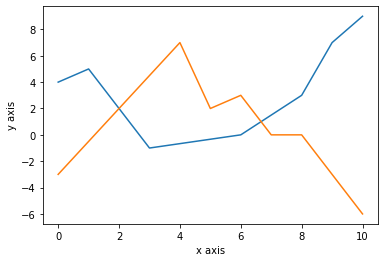

In [35]:
x1 = np.array([0, 1, 3, 6, 8, 9, 10])
y1 = np.array([4, 5, -1, 0, 3, 7, 9])

x2 = np.array([0, 4, 5, 6, 7, 8, 10])
y2 = np.array([-3, 7, 2, 3, 0, 0, -6])

plt.figure()
plt.plot(x1, y1)
plt.plot(x2, y2)

plt.xlabel("x axis")
plt.ylabel("y axis")

## Saving arrays to disk and loading them again

In [36]:
# Save numpy arrays to disk
save_dir = './results'
np.save(f'{save_dir}/array_x1.npy', x1)
np.savez(f'{save_dir}/arrays_x1_y1.npz', array_x1=x1, array_y1=y1)
print("Arrays saved to disk.")

Arrays saved to disk.


In [37]:
# Load numpy arrays from disk
a_loaded = np.load(f'{save_dir}/array_x1.npy')     # loads a single array
b_loaded = np.load(f'{save_dir}/arrays_x1_y1.npz') # loads multiple arrays
x1_loaded = b_loaded['array_x1'] # access array by its name
y1_loaded = b_loaded['array_y1'] 
print("Loaded x1: ", x1_loaded)
print("Loaded y1: ", y1_loaded)
assert np.array_equal(x1, x1_loaded) # verify that loaded array matches original
assert np.array_equal(y1, y1_loaded)
print("Arrays loaded successfully and match the originals.")

Loaded x1:  [ 0  1  3  6  8  9 10]
Loaded y1:  [ 4  5 -1  0  3  7  9]
Arrays loaded successfully and match the originals.


## Creating multiple subplots in one figure

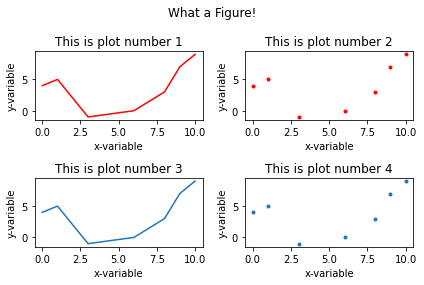

In [ ]:
# Creating a figure with multiple subplots
fig, axes = plt.subplots(ncols=2, nrows=2)
((ax1, ax2), (ax3, ax4)) = axes
ax1.plot(x1, y1, color="red")
ax2.scatter(x1, y1, color="red", marker=".")
ax3.plot(x1, y1)
ax4.scatter(x1, y1, marker=".")

for i, ax in enumerate(axes.flatten(), start=1):
    ax.set_title(f"This is plot number {i}")
    ax.set_xlabel("x-variable")
    ax.set_ylabel("y-variable")
fig.suptitle("What a Figure!")
fig.tight_layout()
plt.show()

## Saving figures

In [50]:
fig.savefig("images/fig.png")
fig.savefig("images/fig.svg")  # Vector graphics are supported out of the box!

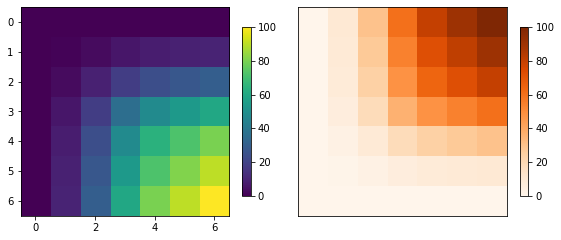

In [51]:
# Plotting images with different origins and colormaps
data = np.outer(x1, x1)

def plot_images(data):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 5))
    img1 = ax1.imshow(data)
    img2 = ax2.imshow(data, origin="lower", cmap="Oranges")
    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.colorbar(img1, shrink=.5, ax=ax1)
    plt.colorbar(img2, shrink=.5, ax=ax2)
    fig.tight_layout()

plot_images(data)

# For more professional images, check out seaborn (code also provided): https://seaborn.pydata.org/examples/index.html
